# RETAIL_ANALYSIS_PROJECT

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

## Load and Inspect the dataset.

In [2]:
df = pd.read_csv("OnlineRetail.csv", encoding= 'latin1') 

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(5268)

In [8]:
# Creating a Revenue column 
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [9]:
#check : new column revenue 
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


### Understanding Missing Values

In [10]:
# Creating a Copy of the Original Dataset : 
# Naver clean the original Dataset directly 

df_clean = df.copy()

In [11]:
# check shape: 
df_clean.shape

(541909, 9)

In [12]:
# column wise total null values. 
df_clean.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
Revenue             0
dtype: int64

In [13]:
# calculating percentage. 
missing = df_clean.isnull().sum() 
missing_percent = (missing / len(df_clean)) * 100  

pd.DataFrame({
    'Missing values': missing, 
    'Percentage' : missing_percent
}).sort_values(by='Missing values', ascending=False)

,Missing values,Percentage
CustomerID,135080,24.926694
Description,1454,0.268311
InvoiceNo,0,0.000000
StockCode,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
Country,0,0.000000
Revenue,0,0.000000


### Investigate Missing Customer IDs 
Before deleting anything, let's understand what these rows represent. 

In [14]:
df_clean[df_clean['CustomerID'].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom,0.00
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom,2.51
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom,5.02
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom,3.40
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom,3.32


In [15]:
df_clean[df_clean['CustomerID'].isnull()].shape

(135080, 9)

Why?

Many online retail datasets have:

Registered customers → CustomerID present
Guest customers → CustomerID missing

We need to decide whether to keep or remove them.

### Check Duplicate Rows
Why?

Duplicate transactions can inflate:

Revenue
Product counts
Customer activity

In [16]:
df_clean.duplicated().sum()

np.int64(5268)

In [17]:
# Duplicate exist: 
duplicate_rows = df_clean[df_clean.duplicated()] 
duplicate_rows.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom,1.25
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom,2.10
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom,2.95
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom,4.95
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom,2.95


### Investigate Negative Quantities. 
Why?

In this dataset:

Negative quantities usually indicate:

* Returns
* Refunds
* Cancelled orders

We need to identify them separately.

In [18]:
df_clean[df_clean['Quantity'] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,-6.96


In [19]:
df_clean[df_clean['Quantity'] < 0].shape

(10624, 9)

### Check for Cancelled Orders 
Why?

Invoices starting with:

C536379

are cancellation transactions.

In [20]:
df_clean[df_clean['InvoiceNo'].astype(str).str.startswith('C')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,-6.96


In [21]:
df_clean[df_clean['InvoiceNo'].astype(str).str.startswith('C')].shape

(9288, 9)

### Check Invalid Prices 

In [22]:
df_clean[df_clean['UnitPrice'] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom,0.0
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom,0.0
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom,0.0
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom,0.0
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom,0.0


In [23]:
df_clean[df_clean['UnitPrice'] <= 0].shape

(2517, 9)

## Data Cleaning

### Data Cleaning Decision Log

| Issue               | Count   | Decision           |
| ------------------- | ------- | ------------------ |
| Missing CustomerID  | 135,080 | Keep (temporarily) |
| Missing Description | 1,454   | Remove             |
| Duplicate Rows      | 5,268   | Remove             |
| Negative Quantity   | 10,624  | Remove             |
| Cancelled Orders    | 9,288   | Remove             |
| UnitPrice ≤ 0       | 2,517   | Remove             |



In [24]:
type(df_clean)

pandas.core.frame.DataFrame

1. Removing missing descriptions 

In [25]:
df_clean = df_clean.dropna(subset=['Description'])

In [26]:
# checking null values 
df_clean[df_clean['Description'].isnull()].shape

(0, 9)

2. Remove duplicate rows 

In [27]:
df_clean = df_clean.drop_duplicates()

In [28]:
df_clean.duplicated().sum()

np.int64(0)

3. Remove cancelled invoices 

In [29]:
df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

In [30]:
df_clean.shape

(525936, 9)

In [31]:
df_clean[df_clean["InvoiceNo"].astype(str).str.startswith("C")].shape

(0, 9)

4. Remove negative quantities

In [32]:
df_clean = df_clean[df_clean['Quantity'] > 0]

In [33]:
# checking for negative quantities. 
df_clean[df_clean['Quantity'] < 0].shape

(0, 9)

5. Remove zero or negative prices

In [34]:
df_clean = df_clean[df_clean['UnitPrice'] > 0]

In [35]:
# checking fro zero or negative prices. 
df_clean[df_clean['UnitPrice'] < 0].shape

(0, 9)

In [36]:
print(df_clean.shape)
print(df_clean.isnull().sum())

(524878, 9)
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     132186
Country             0
Revenue             0
dtype: int64


## Feature Engineering 

create new columns from the InvoiceDate. This is one of the most important steps because it enables time-based analysis.

In [37]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    524878 non-null  object 
 1   StockCode    524878 non-null  object 
 2   Description  524878 non-null  object 
 3   Quantity     524878 non-null  int64  
 4   InvoiceDate  524878 non-null  object 
 5   UnitPrice    524878 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      524878 non-null  object 
 8   Revenue      524878 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 40.0+ MB


Here we found the Dtype of InvoiceDate is object so it need to convert into datetime. 

In [38]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [39]:
# again check Dtype. 
df_clean['InvoiceDate'].dtype

dtype('<M8[ns]')

### Create Time-Based Features 

In [40]:
# Year 
df_clean['year'] = df_clean['InvoiceDate'].dt.year

# Month Number 
df_clean["Month"] = df_clean['InvoiceDate'].dt.month 

# Month Name 
df_clean["Month_Name"] = df_clean["InvoiceDate"].dt.month_name()

# Day 
df_clean["Day"] = df_clean["InvoiceDate"].dt.day 

# Day Name
df_clean["Day_Name"] = df_clean["InvoiceDate"].dt.day_name() 

# Hour 
df_clean["Hour"] = df_clean["InvoiceDate"].dt.hour

# Quarter 
df_clean["Quarter"] = df_clean["InvoiceDate"].dt.quarter 

# Weekday (Monday=0, Sunday=6)
df_clean["Weekday"] = df_clean["InvoiceDate"].dt.weekday

In [41]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,year,Month,Month_Name,Day,Day_Name,Hour,Quarter,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,December,1,Wednesday,8,4,2
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday,8,4,2
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,December,1,Wednesday,8,4,2
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday,8,4,2
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday,8,4,2


## Exploratory Data Analysis (EDA) 

1. Dataset Overview
2. Sales Analysis
3. Product Analysis
4. Customer Analysis
5. Country Analysis
6. Time-Based Analysis

### 1: Dataset Overview

This gives stakeholders a quick summary of the business. 

#### KPI 1 - Total Transations 

Why nunique()?

Each invoice represents one transaction.

Using count() would count every product line, not every order.

In [42]:
total_transactions = df_clean['InvoiceNo'].nunique()

print(f"Total Transactions: {total_transactions}")

Total Transactions: 19960


#### KPI 2 - Total Products Sold  
This tells us how many units were sold. 

In [43]:
total_products = df_clean['Quantity'].sum() 

print(f"Total Products Sold: {total_products}")

Total Products Sold: 5572420


#### KPI 3 - Unique Products 
Shows product diversity. 

In [44]:
unique_products = df_clean['StockCode'].nunique() 
print(f"Unique Products: {unique_products}")

Unique Products: 3922


#### KPI 4 - Total Customers 
nunique() automatically ignores NaN. 

In [45]:
total_customers = df_clean["CustomerID"].nunique()

print(f"Total customers: {total_customers}")

Total customers: 4338


#### KPI 5 - Countries Served 


In [46]:
countries = df_clean['Country'].nunique()

print(f"Countries Served: {countries}")

Countries Served: 38


#### KPI 6 - Total Revenue 

In [47]:
total_revenue = df_clean['Revenue'].sum() 

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $10,642,110.80


#### KPI 7 - Average Order Value (AOV) 
total Revenue / total Transactions 

In [48]:
average_order_value = (
    df_clean['Revenue'].sum() 
    / df_clean['InvoiceNo'].nunique()
)

print(f"Average Order Value: ${average_order_value:.2f}")

Average Order Value: $533.17


#### KPI 8 - Average Products per Order 

In [49]:
average_products = (
    df_clean['Quantity'].sum()
    / df_clean['InvoiceNo'].nunique()
)

print(f"Average Product per Order: {average_products:.2f}")

Average Product per Order: 279.18


#### KPI Summary Table

In [50]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Transactions", 
        "Total Products Sold", 
        "Unique Products", 
        "Total Customers", 
        "Countries Served", 
        "Total Revenue", 
        "Average Order Value", 
        "Average Product per Order"
    ], 
    "Value": [
        total_transactions, 
        total_products, 
        unique_products, 
        total_customers, 
        countries, 
        round(total_revenue, 2), 
        round(average_order_value, 2), 
        round(average_products, 2)
    ]
})

kpi_summary

,Metric,Value
0,Total Transactions,19960.00
1,Total Products Sold,5572420.00
2,Unique Products,3922.00
3,Total Customers,4338.00
4,Countries Served,38.00
5,Total Revenue,10642110.80
6,Average Order Value,533.17
7,Average Product per Order,279.18


### 2: Sales Analysis 
This is where we begin answering real business questions.

#### Q1. What is the Total Revenue? 


In [51]:
print(f"${df_clean['Revenue'].sum():,.2f}")

$10,642,110.80


#### Q2. How does Revenue change every month?
Group revenue by month. 

In [52]:
monthly_sales = (
    df_clean
    .groupby(["Month", "Month_Name"])["Revenue"]
    .sum()
    .reset_index()
    .sort_values("Month")
)

monthly_sales

,Month,Month_Name,Revenue
0,1,January,689811.610
1,2,February,522545.560
2,3,March,716215.260
3,4,April,536968.491
4,5,May,769296.610
5,6,June,760547.010
6,7,July,718076.121
7,8,August,757841.380
8,9,September,1056435.192
9,10,October,1151263.730


#### Q3: Which Month Generated the Highest Revenue? 

In [53]:
# Highest Revenue Months
monthly_sales.sort_values(
    by='Revenue',ascending= False
).head()

,Month,Month_Name,Revenue
10,11,November,1503866.780
11,12,December,1459243.060
9,10,October,1151263.730
8,9,September,1056435.192
4,5,May,769296.610


In [54]:
# Lowest Revenue Months 
monthly_sales.sort_values(
    by='Revenue', ascending=True
).head()

,Month,Month_Name,Revenue
1,2,February,522545.560
3,4,April,536968.491
0,1,January,689811.610
2,3,March,716215.260
6,7,July,718076.121


#### Q4: Monthly Revenue Visualization 

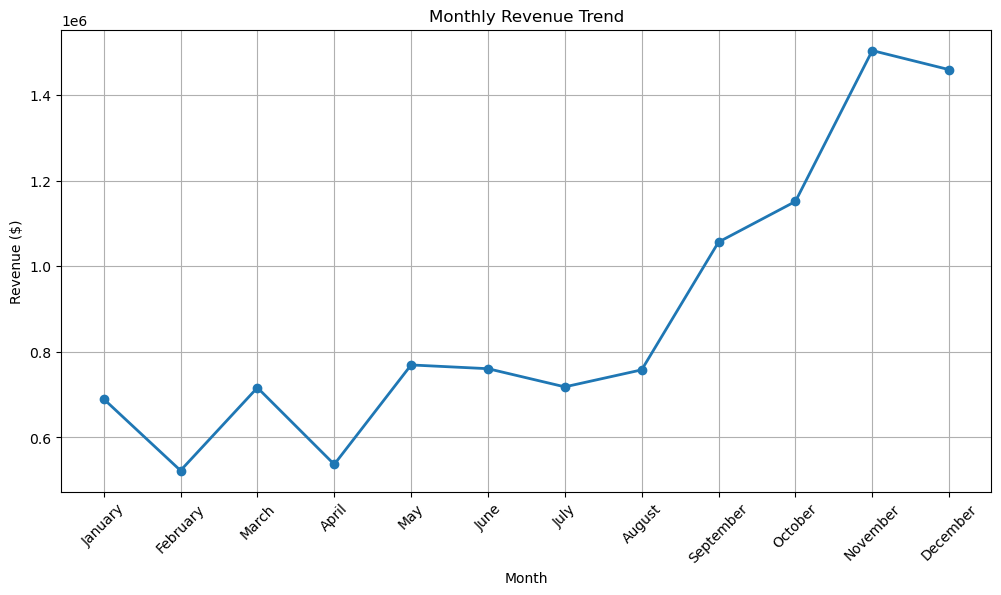

<Figure size 640x480 with 0 Axes>

In [55]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales['Month_Name'], 
    monthly_sales['Revenue'], 
    marker='o', 
    linewidth = 2
)

plt.title("Monthly Revenue Trend") 
plt.xlabel("Month") 
plt.ylabel("Revenue ($)") 
plt.xticks(rotation=45) 

plt.grid(True)

plt.show()

plt.savefig("monthly_revenue_trend.png", dpi=300, bbox_inches="tight")

#### Q5. Monthly Growth (%) 
* Which month experienced the highest growth?
* Which month saw the largest decline?

In [56]:
monthly_sales["Growth_%"] = (
    monthly_sales['Revenue']
    .pct_change() * 100
)

monthly_sales

,Month,Month_Name,Revenue,Growth_%
0,1,January,689811.610,NaN
1,2,February,522545.560,-24.248077
2,3,March,716215.260,37.062740
3,4,April,536968.491,-25.026941
4,5,May,769296.610,43.266620
5,6,June,760547.010,-1.137351
6,7,July,718076.121,-5.584256
7,8,August,757841.380,5.537750
8,9,September,1056435.192,39.400568
9,10,October,1151263.730,8.976276


#### Q6. Average Monthly Revenue 

In [57]:
monthly_sales["Revenue"].mean()

np.float64(886842.5669999999)

### 3: Product Analysis 
Which products drive the business?

#### 1. Top 10 Best-Selling Products (by Quantity)

In [58]:
top_products_quantity = (
    df_clean
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_quantity

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

In [59]:
# Visualization

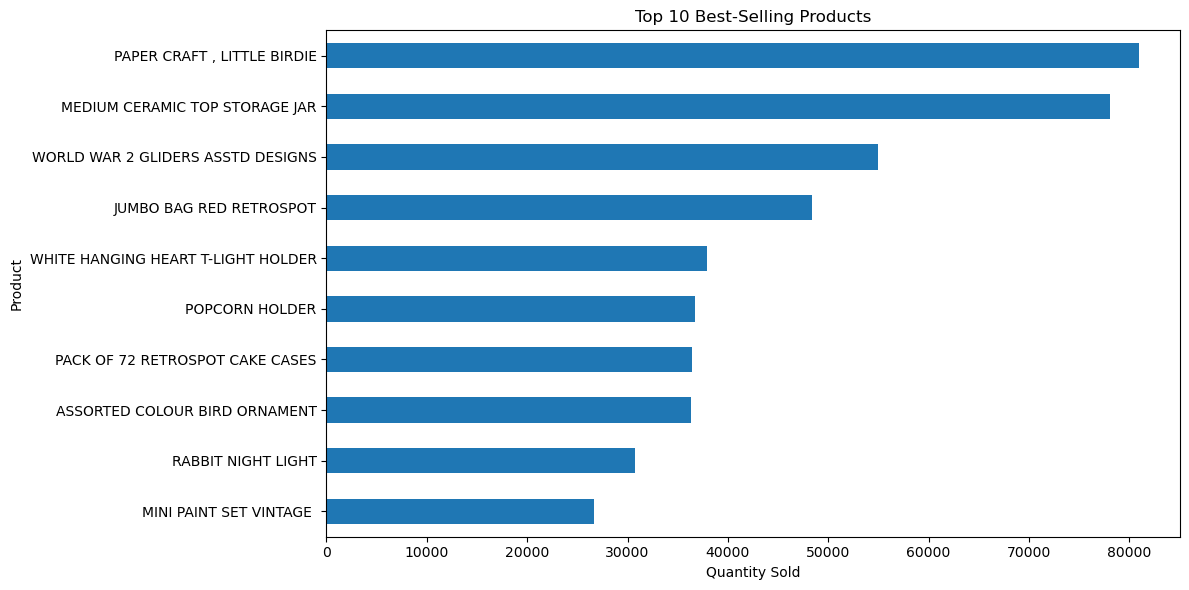

In [60]:
plt.figure(figsize=(12,6)) 

top_products_quantity.sort_values().plot(kind='barh')
plt.title("Top 10 Best-Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product") 

plt.tight_layout()

plt.savefig(
    "visuals/top_10_best_selling_products.png", 
    dpi=300, 
    bbox_inches='tight'
)

plt.show()

#### 2. Top 10 Revenue-Generating Products 
Sometimes a product sells in low quantities but generates high revenue.

In [61]:
top_products_revenue = (
    df_clean
    .groupby("Description")["Revenue"] 
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_revenue

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

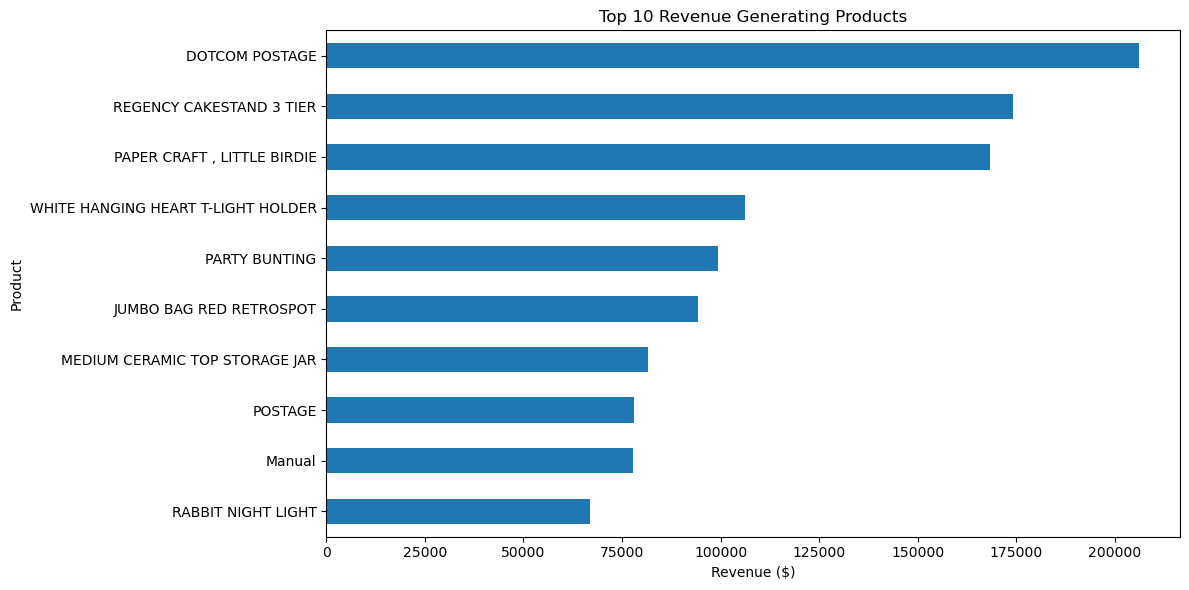

In [62]:
# visualization 

plt.figure(figsize=(12,6)) 

top_products_revenue.sort_values().plot(kind='barh')

plt.title("Top 10 Revenue Generating Products")
plt.xlabel("Revenue ($)")
plt.ylabel("Product")

plt.tight_layout() 

plt.savefig(
    "visuals/top_10_revenue_products.png", 
    dpi=300, 
    bbox_inches='tight'
)

plt.show()

#### 3: Most Frequently Ordered Products 
This tells us which product appear in the largest number of different invoices. 

In [63]:
most_ordered = (
    df_clean 
    .groupby("Description")["InvoiceNo"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

most_ordered

Description
WHITE HANGING HEART T-LIGHT HOLDER    2311
JUMBO BAG RED RETROSPOT               2109
REGENCY CAKESTAND 3 TIER              2007
PARTY BUNTING                         1699
LUNCH BAG RED RETROSPOT               1581
ASSORTED COLOUR BIRD ORNAMENT         1476
SET OF 3 CAKE TINS PANTRY DESIGN      1392
PACK OF 72 RETROSPOT CAKE CASES       1352
LUNCH BAG  BLACK SKULL.               1301
NATURAL SLATE HEART CHALKBOARD        1255
Name: InvoiceNo, dtype: int64

Text(0, 0.5, 'Product')

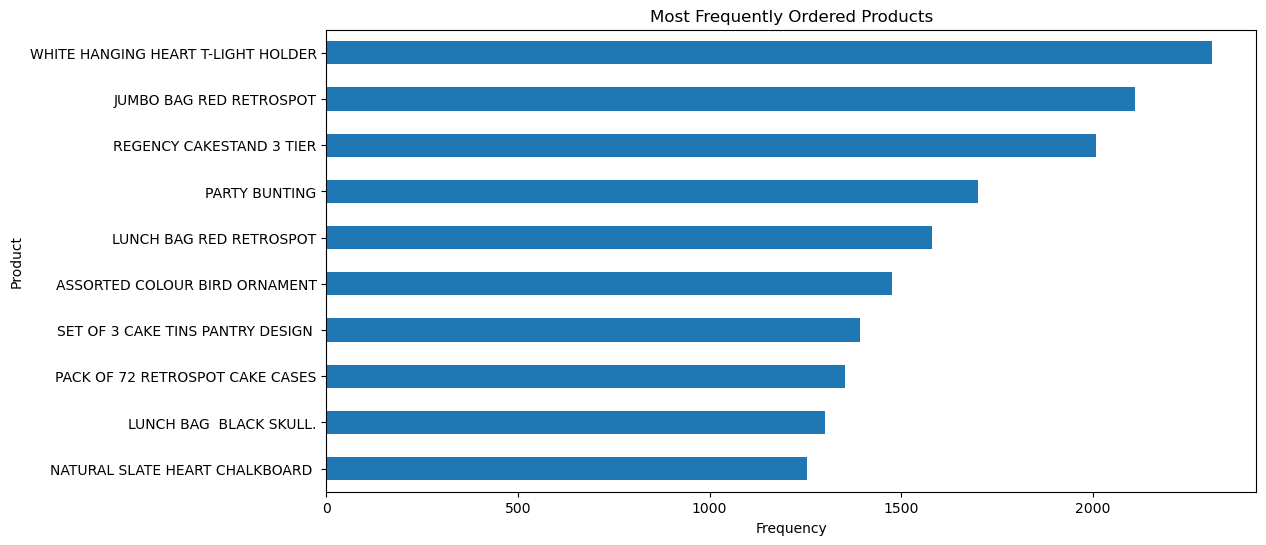

In [64]:
# Visualization 
plt.figure(figsize=(12, 6))

most_ordered.sort_values().plot(kind='barh')

plt.title("Most Frequently Ordered Products") 
plt.xlabel("Frequency")
plt.ylabel("Product")

### 4: Customer Analysis

#### 1. Create a Customer Dataset
we intentionally kept rows with missing CustomerID during cleaning. Now it's time to filter them out because customer analysis requires a valid customer ID.

In [65]:
customer_df = df_clean.dropna(subset=["CustomerID"]).copy()
customer_df.shape

(392692, 17)

In [66]:
#### 2. Top 10 Customers by Revenue 
top_customers_revenue = (
    customer_df
    .groupby("CustomerID")["Revenue"] 
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers_revenue

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

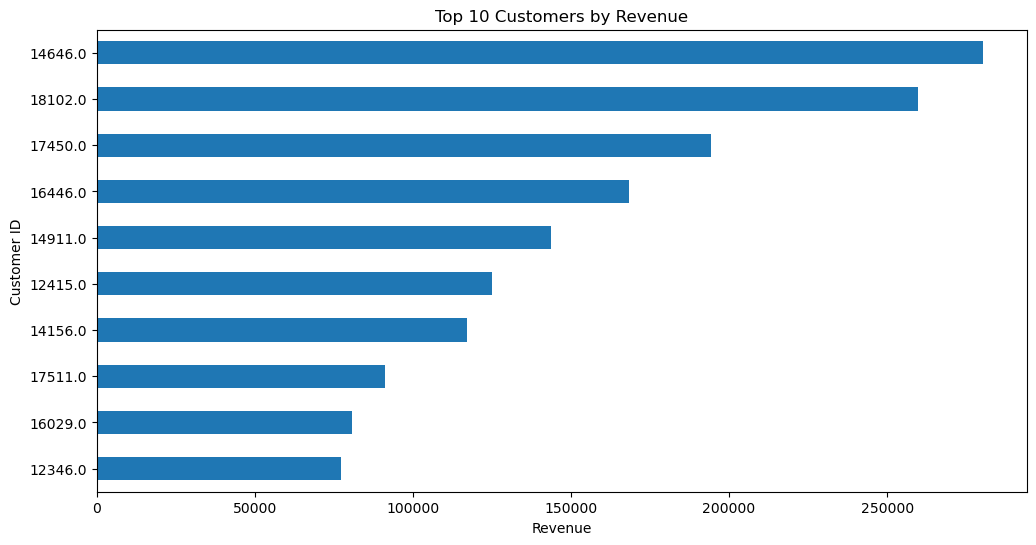

In [67]:
# Visualization 
plt.figure(figsize=(12,6)) 

top_customers_revenue.sort_values().plot(kind='barh')

plt.title("Top 10 Customers by Revenue") 
plt.xlabel("Revenue") 
plt.ylabel("Customer ID") 

plt.show()

#### 3. Top 10 Customers by Number of Orders 

In [68]:
top_customers_orders = (
    customer_df
    .groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

top_customers_orders

CustomerID
12748.0    209
14911.0    201
17841.0    124
13089.0     97
14606.0     93
15311.0     91
12971.0     86
14646.0     73
16029.0     63
13408.0     62
Name: InvoiceNo, dtype: int64

#### 4. Top 10 Customers by Quantity Purchased 

In [69]:
top_customers_quantity = (
    customer_df 
    .groupby("CustomerID")["Quantity"] 
    .sum() 
    .sort_values(ascending=False) 
    .head(10)
) 

top_customers_quantity

CustomerID
14646.0    196915
16446.0     80997
14911.0     80240
12415.0     77374
12346.0     74215
17450.0     69973
17511.0     64549
18102.0     64124
13694.0     63312
14298.0     58343
Name: Quantity, dtype: int64

#### 5. Customer Purchase Frequency 
How many orders does the average customer place? 

This gives you:

* Average orders per customer
* Maximum orders
* Median orders
* Distribution of purchasing behavior

In [70]:
purchase_frequency = (
    customer_df 
    .groupby("CustomerID")["InvoiceNo"] 
    .nunique()
) 

purchase_frequency.describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64

#### 6. Customer Revenue Distribution 
This tells us:

* Average revenue per customer
* Highest-spending customer
* Median customer spend

In [71]:
customer_revenue = (
    customer_df
    .groupby("CustomerID")["Revenue"]
    .sum()
) 

customer_revenue.describe()

count      4338.000000
mean       2048.688081
std        8985.230220
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: Revenue, dtype: float64

#### 7. Top 10 Customers Summary 
Instead of separate tables, create one consolidated summary:

In [72]:
customer_summary = (
    customer_df 
    .groupby("CustomerID") 
    .agg(
        Total_Orders = ("InvoiceNo", "nunique"), 
        Total_Products = ("Quantity", "sum"), 
        Total_Revenue = ("Revenue", "sum")
    ).sort_values("Total_Revenue", ascending=False)
)

customer_summary.head(10)

,Total_Orders,Total_Products,Total_Revenue
CustomerID,,,
14646.0,73,196915,280206.02
18102.0,60,64124,259657.30
17450.0,46,69973,194390.79
16446.0,2,80997,168472.50
14911.0,201,80240,143711.17
12415.0,21,77374,124914.53
14156.0,55,57768,117210.08
17511.0,31,64549,91062.38
16029.0,63,40108,80850.84


### 5: Country Analysis  
Business Questions

We want to answer:

1. Which countries generate the highest revenue?
2. Which countries place the most orders?
3. Which countries have the most customers?
4. What percentage of revenue comes from the UK?
5. Which international markets have growth potential?

#### 1. Top 10 Countries by Revenue 


In [73]:
country_revenue = (
    df_clean 
    .groupby("Country", as_index=False)["Revenue"] 
    .sum() 
    .sort_values(by="Revenue", ascending=False)
) 

country_revenue.head(10)

,Country,Revenue
36,United Kingdom,9001744.094
24,Netherlands,285446.340
10,EIRE,283140.520
14,Germany,228678.400
13,France,209625.370
0,Australia,138453.810
31,Spain,61558.560
33,Switzerland,57067.600
3,Belgium,41196.340
32,Sweden,38367.830


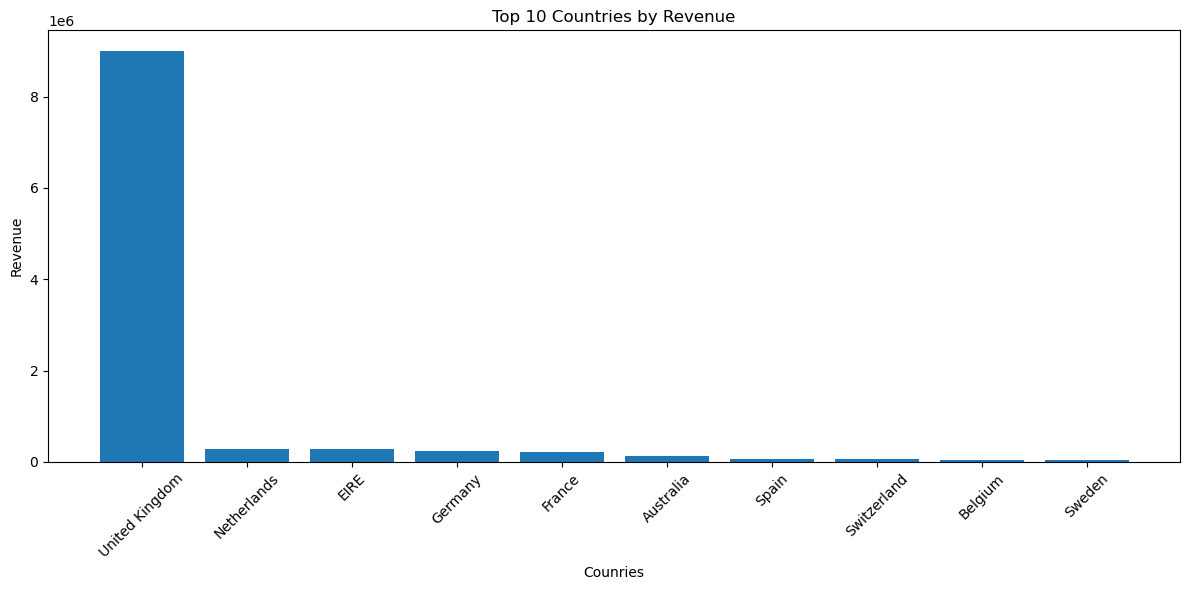

In [74]:
# Visualization 

plt.figure(figsize=(12, 6))

top10 = country_revenue.head(10)

plt.bar(top10["Country"], top10["Revenue"])
plt.title("Top 10 Countries by Revenue") 
plt.xlabel("Counries") 
plt.ylabel("Revenue") 

plt.xticks(rotation=45) 

plt.tight_layout()

plt.show()

#### 2. Top Countries by Number of Orders 
which countries place the highest number of orders? 

In [75]:
country_orders = (
    df_clean
    .groupby("Country", as_index=False)["InvoiceNo"]
    .nunique()
    .rename(columns={"InvoiceNo":"Total_Orders"})
    .sort_values(by="Total_Orders", ascending=False)
)

country_orders.head(10)

,Country,Total_Orders
36,United Kingdom,18019
14,Germany,457
13,France,392
10,EIRE,288
3,Belgium,98
24,Netherlands,94
31,Spain,90
27,Portugal,58
0,Australia,57
33,Switzerland,54


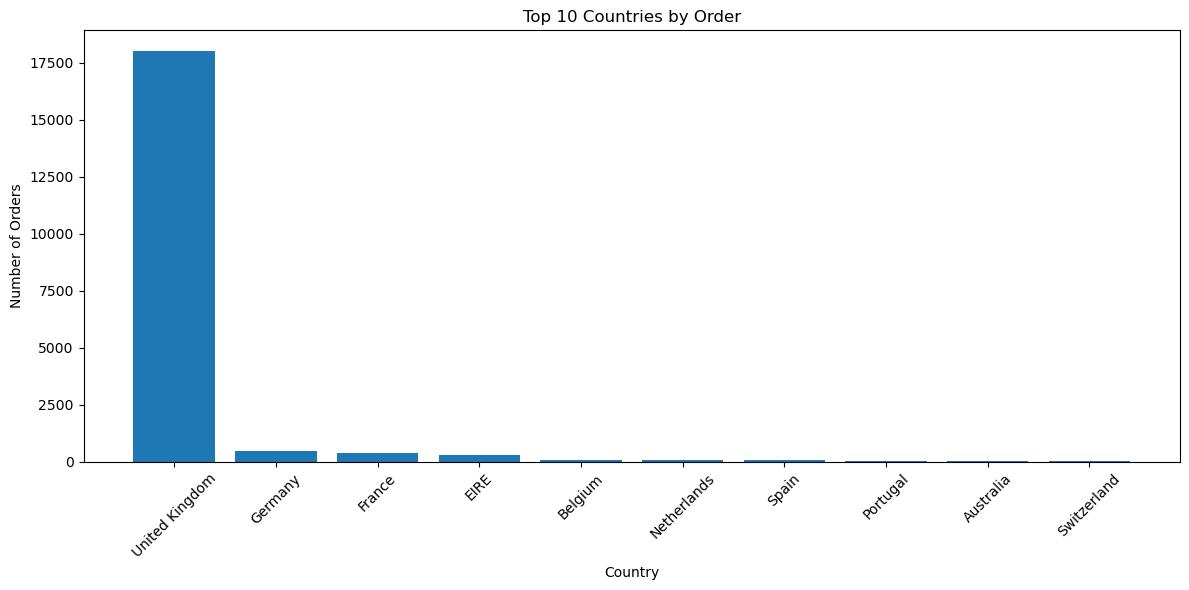

In [76]:
# Visualization 

plt.figure(figsize=(12, 6)) 

top10 = country_orders.head(10) 

plt.bar(top10["Country"], top10["Total_Orders"]) 

plt.title("Top 10 Countries by Order") 
plt.xlabel("Country") 
plt.ylabel("Number of Orders") 

plt.xticks(rotation=45) 

plt.tight_layout()

plt.show()

#### 3. Countries by Customer Count 
Which countries have the largest customer base? 

In [77]:
country_customers = (
    customer_df 
    .groupby("Country", as_index=False)["CustomerID"] 
    .nunique() 
    .rename(columns={"CustomerID":"Customers"}) 
    .sort_values(by="Customers", ascending=False)
)

country_customers.head(10)

,Country,Customers
35,United Kingdom,3920
14,Germany,94
13,France,87
30,Spain,30
3,Belgium,25
32,Switzerland,21
26,Portugal,19
18,Italy,14
12,Finland,12
1,Austria,11


#### 4. Revenue Contribution (%)

In [78]:
country_revenue["Revenue_%"] = (
    country_revenue["Revenue"] 
    / country_revenue["Revenue"].sum()
) * 100

country_revenue.head(10)

,Country,Revenue,Revenue_%
36,United Kingdom,9001744.094,84.586078
24,Netherlands,285446.340,2.682234
10,EIRE,283140.520,2.660567
14,Germany,228678.400,2.148807
13,France,209625.370,1.969772
0,Australia,138453.810,1.301000
31,Spain,61558.560,0.578443
33,Switzerland,57067.600,0.536243
3,Belgium,41196.340,0.387107
32,Sweden,38367.830,0.360528


#### 5. Top 10 Revenue Share 


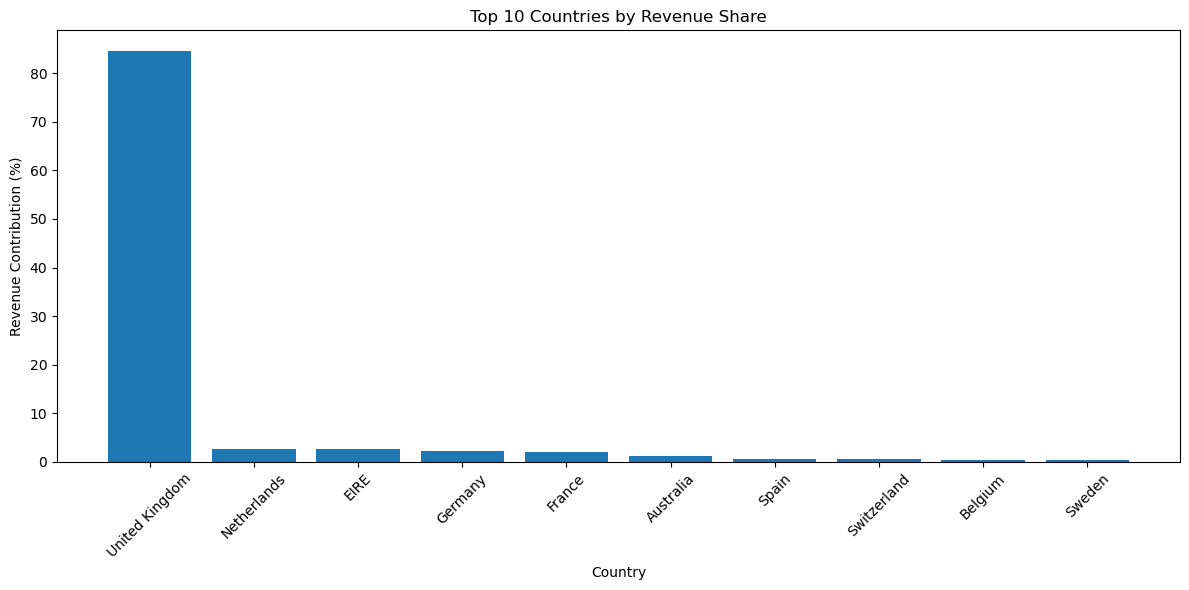

In [79]:
top10 = country_revenue.head(10) 

plt.figure(figsize=(12, 6)) 

plt.bar(
    top10["Country"], 
    top10["Revenue_%"]
)

plt.title("Top 10 Countries by Revenue Share") 
plt.xlabel("Country") 
plt.ylabel("Revenue Contribution (%)") 

plt.xticks(rotation=45) 

plt.tight_layout()

plt.show()

### 6: Time Analysis 
Time Analysis Roadmap

We'll answer these business questions:

1. Which month generates the highest revenue?

(Already done, but we'll summarize.)

2. Which day of the week generates the highest revenue?
3. Which day receives the highest number of orders?
4. Which hour has the highest number of orders?
5. Which hour generates the highest revenue?
6. Which quarter performs the best?
7. Heatmap of Orders (Weekday × Hour)

This last visualization is very impressive in a portfolio.

#### 1. Revenue by Day of Week 

In [80]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,year,Month,Month_Name,Day,Day_Name,Hour,Quarter,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,December,1,Wednesday,8,4,2
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday,8,4,2
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,December,1,Wednesday,8,4,2
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday,8,4,2
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1,Wednesday,8,4,2


In [81]:
weekday_revenue = (
    df_clean 
    .groupby(["Weekday", "Day_Name"], as_index=False)["Revenue"] 
    .sum() 
    .sort_values("Weekday")
) 

weekday_revenue

,Weekday,Day_Name,Revenue
0,0,Monday,1775782.071
1,1,Tuesday,2175700.511
2,2,Wednesday,1847074.380
3,3,Thursday,2199292.570
4,4,Friday,1837470.491
5,6,Sunday,806790.781


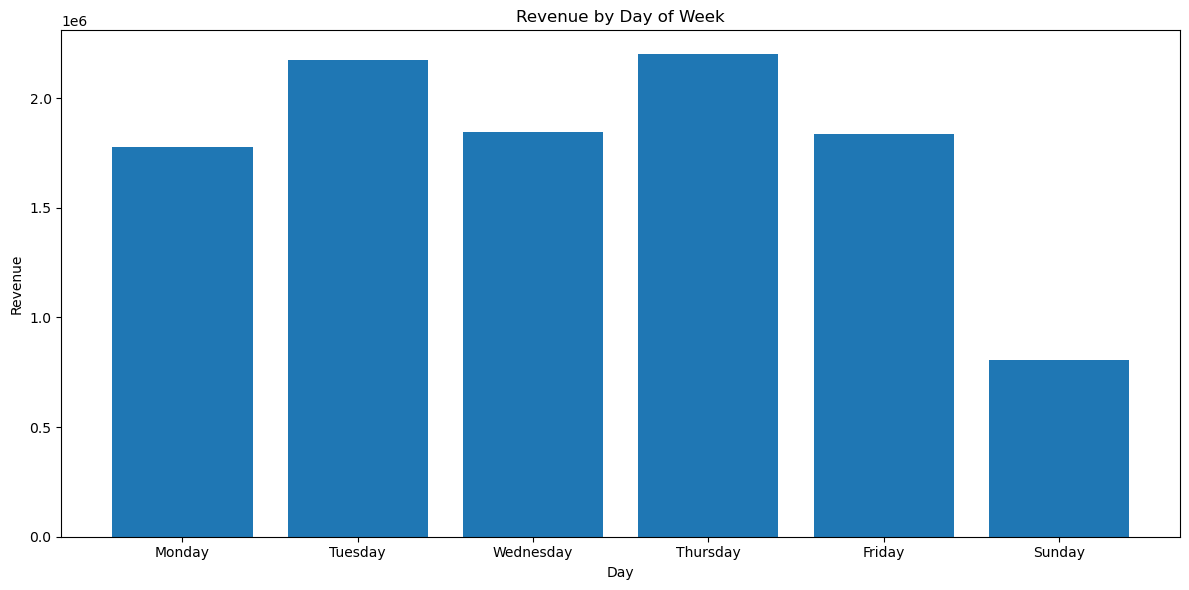

In [82]:
# Visualization 

plt.figure(figsize=(12, 6)) 

plt.bar(
    weekday_revenue["Day_Name"], 
    weekday_revenue["Revenue"]
)

plt.title("Revenue by Day of Week") 
plt.xlabel("Day") 
plt.ylabel("Revenue")

plt.tight_layout() 

plt.show()

#### 2. Order by Day 
Which day receives the most customer orders?

In [83]:
weekday_orders = (
    df_clean 
    .groupby(["Weekday", "Day_Name"], as_index=False)["InvoiceNo"]
    .nunique()
    .rename(columns={"InvoiceNo":"Orders"})
    .sort_values("Weekday")
)

weekday_orders

,Weekday,Day_Name,Orders
0,0,Monday,3126
1,1,Tuesday,3554
2,2,Wednesday,3690
3,3,Thursday,4246
4,4,Friday,3140
5,6,Sunday,2204


#### 3. Orders by Hour 
This tells us the busiest shopping hour. 

In [84]:
hourly_orders = (
    df_clean 
    .groupby("Hour", as_index=False)["InvoiceNo"] 
    .nunique() 
    .rename(columns={"InvoiceNO":"Orders"})
)

hourly_orders

,Hour,InvoiceNo
0,6,1
1,7,29
2,8,566
3,9,1484
4,10,2361
5,11,2396
6,12,3220
7,13,2753
8,14,2457
9,15,2336


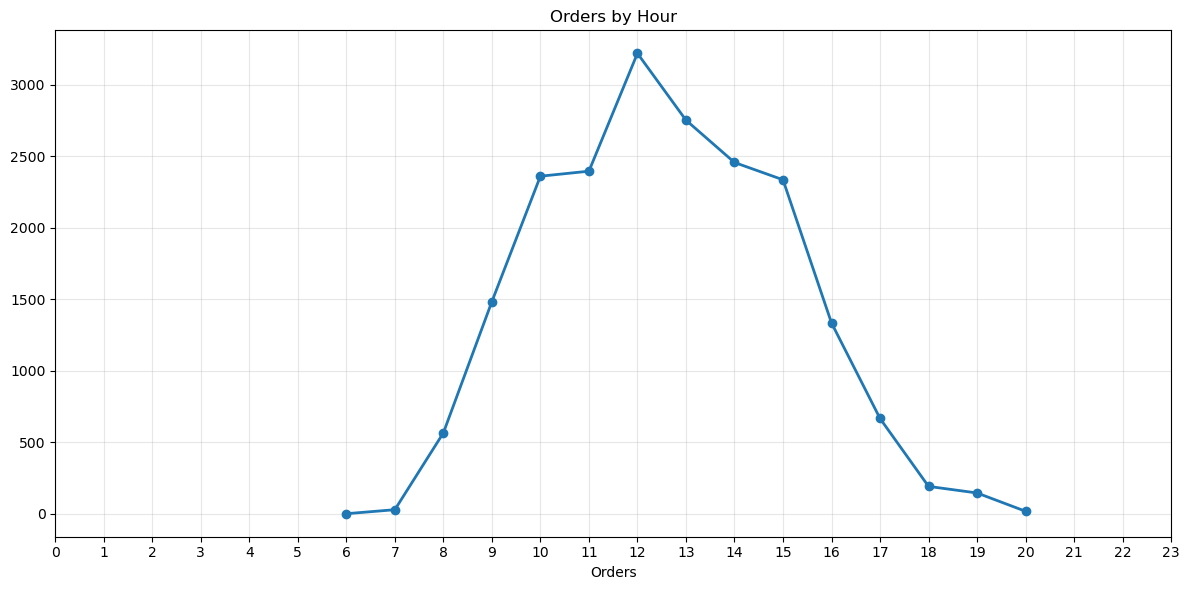

In [85]:
# Visualization 
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_orders["Hour"],
    hourly_orders["InvoiceNo"],
    marker = "o",
    linewidth = 2
)

plt.title("Orders by Hour") 
plt.xlabel("Hour of Day")
plt.xlabel("Orders")

plt.xticks(range(0, 24))

plt.grid(alpha=0.3) 

plt.tight_layout() 

plt.show()

#### 4. Revenue by Hour 

In [86]:
hourly_revenue = (
    df_clean
    .groupby("Hour", as_index=False)["Revenue"]
    .sum()
)

hourly_revenue

,Hour,Revenue
0,6,4.250
1,7,31059.210
2,8,283750.680
3,9,990054.991
4,10,1444814.771
5,11,1236573.290
6,12,1439324.660
7,13,1261195.200
8,14,1177907.521
9,15,1350333.310


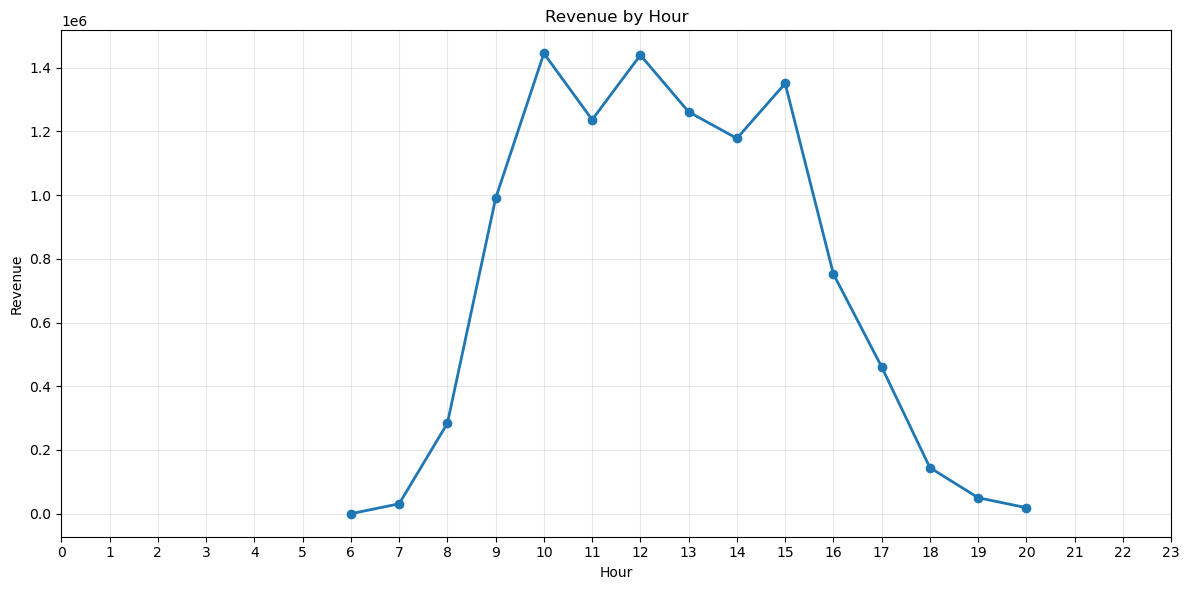

In [87]:
# Visualization 

plt.figure(figsize=(12, 6)) 

plt.plot(
    hourly_revenue["Hour"], 
    hourly_revenue["Revenue"], 
    marker="o",
    linewidth=2
)

plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue") 

plt.xticks(range(0,24))

plt.grid(alpha=0.3) 

plt.tight_layout()

plt.show()

#### 5. Revenue by Quarter 

In [88]:
quarter_revenue = (
    df_clean
    .groupby("Quarter", as_index=False)["Revenue"]
    .sum()
) 

quarter_revenue

,Quarter,Revenue
0,1,1928572.430
1,2,2066812.111
2,3,2532352.693
3,4,4114373.570


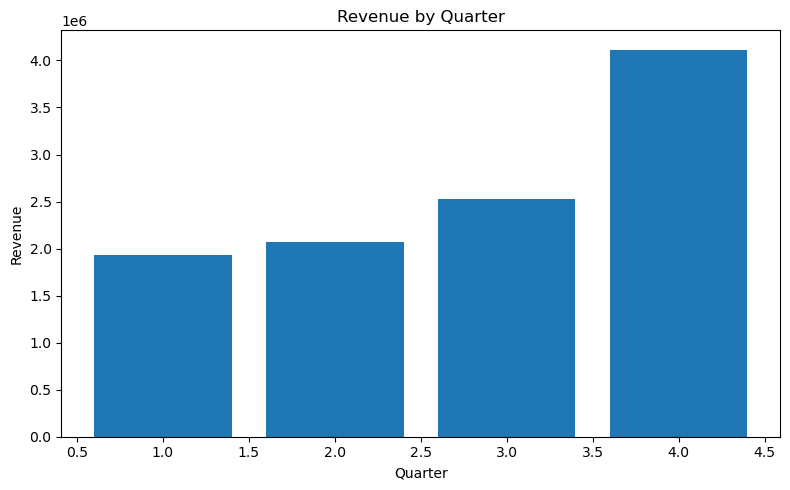

In [90]:
# Visualization 

plt.figure(figsize=(8,5)) 

plt.bar(
    quarter_revenue["Quarter"], 
    quarter_revenue["Revenue"] 
)

plt.title("Revenue by Quarter") 
plt.xlabel("Quarter")
plt.ylabel("Revenue") 

plt.tight_layout() 

plt.show()

## Business Insights & Recommendations

### Business Insights 

#### 1. Strong Business Insights 
Revenue increased significantly during the last quarter of the year. November generated the highest monthly revenue of approximately £1.50 million, followed closely by December with £1.46 million, indicating strong seasonal demand during the holiday shopping period.

#### 2. February Recorded the Lowest Sales

February generated the lowest monthly revenue (~£522K), suggesting a seasonal decline after the holiday season. This presents an opportunity for promotional campaigns during this period.

#### 3. The Business Generated Over £10.64 Million in Revenue

After cleaning the data, completed transactions generated approximately £10.64 million in revenue across 19,960 unique orders.

### 4. Revenue Is Concentrated in a Few Products

The highest revenue-generating products were:

Product	                         Revenue (£)

DOTCOM POSTAGE	                 206,248.77

REGENCY CAKESTAND 3 TIER	     174,156.54

PAPER CRAFT, LITTLE BIRDIE	     168,469.60

These products contribute significantly to overall revenue and should receive priority in inventory planning.

#### 5. High-Value Customers Drive Revenue

Customer 14646 generated the highest revenue (£280,206) across 73 orders.

Customer 14911 placed the highest number of orders (201) while generating over £143K in revenue.

This indicates that a relatively small group of customers contributes a large share of total revenue.

#### 6. United Kingdom Dominates Sales

The United Kingdom generated approximately £9.0 million in revenue, far exceeding every other country.

The next largest markets were:

Netherlands
EIRE (Ireland)
Germany
France

This shows the business is highly dependent on the UK market.

#### 7. International Markets Show Growth Potential

Although international markets contribute much less revenue than the UK, countries such as Germany, France, Netherlands, and Australia have established customer bases that could support future expansion.

#### 8. Thursday Is the Highest Revenue Day

Revenue by weekday shows:

Thursday → Highest revenue (~£2.20M)
Tuesday → Second highest (~£2.18M)
Monday → Lower than Tuesday and Thursday
Sunday → Lowest revenue

This suggests customer purchasing activity peaks during the middle of the week.

#### 9. Customers Shop Mostly Between 10 AM and 3 PM

Order volume peaks during business hours.

The highest number of orders occurs around:

12 PM
1 PM
2 PM

After 5 PM, order volume declines rapidly.

This indicates that customers primarily purchase during standard working hours.

#### 10. Orders Are Highly Concentrated During the Day

Very few transactions occur before 8 AM or after 7 PM, suggesting limited demand outside normal business hours.

#### 11. Wholesale Purchasing Behavior

The average order contains approximately 279 products, indicating that many customers place large-volume orders rather than purchasing only a few items.

#### 12. Customer Base

The company serves:

4,338 unique customers
Across 38 countries

This demonstrates a broad international customer network despite revenue being concentrated in a few markets.

### Business Recommendations 

#### Recommendation 1

Introduce targeted marketing campaigns during February and April, when sales are comparatively lower, to reduce seasonal declines.

#### Recommendation 2

Ensure adequate inventory for the top-selling products, especially:

* DOTCOM POSTAGE
* REGENCY CAKESTAND 3 TIER
* PAPER CRAFT, LITTLE BIRDIE

to avoid stock shortages during peak demand.

#### Recommendation 3

Launch a VIP loyalty program for high-value customers, particularly those generating significant revenue, to improve customer retention.

#### Recommendation 4

Reduce business dependence on the UK by expanding marketing efforts in:

Germany
France
Netherlands
Australia

These countries already demonstrate promising sales performance.

#### Recommendation 5

Schedule promotional emails and digital advertising between 10 AM and 2 PM, when customer purchasing activity is highest.

#### Recommendation 6

Increase warehouse staffing and inventory availability during Q4, particularly in November and December, to handle peak demand efficiently.

#### Recommendation 7

Analyze customer purchasing patterns further using RFM (Recency, Frequency, Monetary) analysis to improve customer segmentation and personalized marketing.

## Project Conclusion 

This project analyzed over 500,000 retail transactions using Python and the Pandas library. The data was cleaned, transformed, and analyzed to uncover valuable business insights related to sales performance, customer behavior, product trends, country-wise performance, and time-based purchasing patterns.

The analysis identified seasonal sales trends, high-value customers, top-performing products, key international markets, and peak purchasing times. Based on these findings, actionable business recommendations were proposed to support data-driven decision-making.

This project demonstrates practical skills in data cleaning, exploratory data analysis (EDA), feature engineering, business analytics, and data visualization using Pandas, NumPy, Matplotlib, and Seaborn.

# THANK YOU